# Breaking Down the 90s Hit Formula


The dataset contains metadata on popular 1990s tracks, including audio features such as tempo, energy, danceability, popularity, and instrumentalness.
- No additional data wrangling or cleaning was required as the dataset was already structured and clean.
- We used `.value_counts()`, `.groupby()`, and binning techniques to prepare data for visualization.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns

df = pd.read_csv('/content/1990sClassicHits.csv')
print(df.head(8))

                 Track          Artist Duration  Time_Signature  Danceability  \
0  Everybody Everybody       Black Box     4:11               4         0.645   
1         Close To You     Maxi Priest     3:45               4         0.590   
2               Do Me!  Bell Biv DeVoe     3:56               4         0.615   
3           Everything     Jody Watley     4:05               4         0.704   
4        What It Takes       Aerosmith     3:21               4         0.672   
5              Alright   Janet Jackson     3:39               4         0.796   
6            Love Song           Tesla     2:28               4         0.640   
7               Poison  Bell Biv DeVoe     3:32               3         0.689   

   Energy  Key  Loudness  Mode  Speechiness  Acousticness  Instrumentalness  \
0   0.795    7   -12.095     1       0.0527        0.3470          0.003890   
1   0.727    6    -7.955     1       0.0706        0.0259          0.000065   
2   0.534    9    -6.719     0   

# Data Cleaning Overview

- The dataset contains metadata on popular 1990s tracks, including audio features such as tempo, energy, danceability, popularity, and instrumentalness.
- No additional data wrangling or cleaning was required as the dataset was already structured and clean.
- We used `.value_counts()`, `.groupby()`, and binning techniques to prepare data for visualization.


#SECTION I: INDIVIDUAL, COMPARATIVE AND GROUPED VISUALIZATIONS

**1. Top Artists by Hit (First 5 years vs. Last 5 years)**

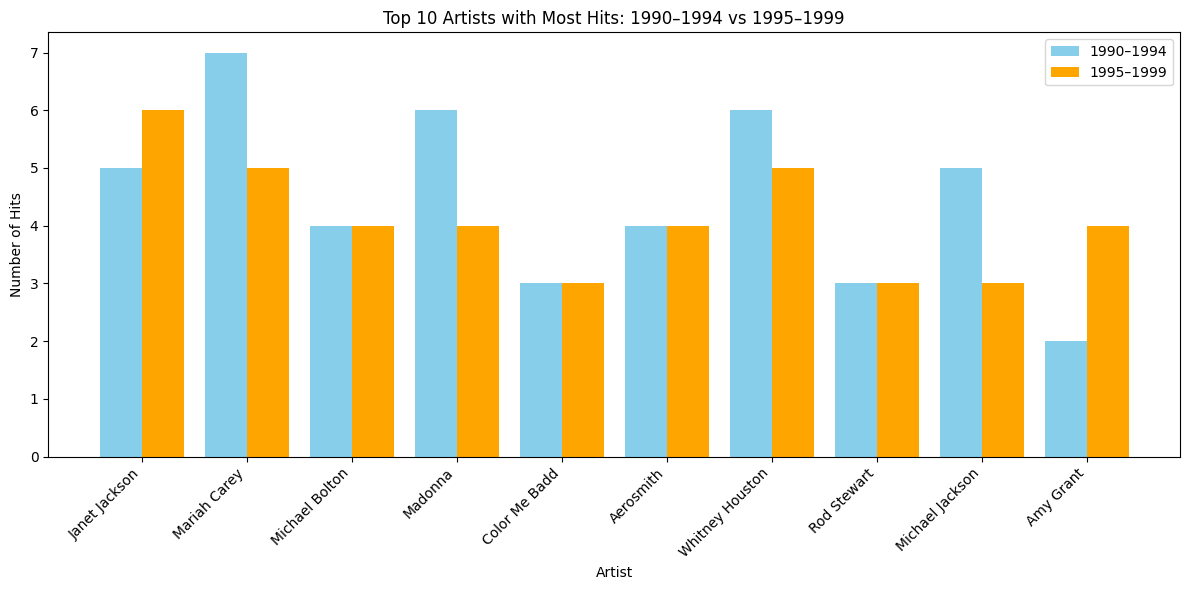

In [9]:
import matplotlib.pyplot as plt

artists_first_half = ['Janet Jackson', 'Mariah Carey', 'Michael Bolton', 'Madonna', 'Color Me Badd',
                      'Aerosmith', 'Whitney Houston', 'Rod Stewart', 'Michael Jackson', 'Amy Grant']
hits_first_half = [5, 7, 4, 6, 3, 4, 6, 3, 5, 2]

artists_second_half = ['TLC', 'Boyz Il Men', 'Artist', 'Whitney Houston', 'Hootie & the Blowfish',
                       'Sheryl Crow', 'Mariah Carey', 'Brandy', 'Dru Hill', 'Spice Girls']
hits_second_half = [6, 5, 4, 4, 3, 4, 5, 3, 3, 4]

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(artists_first_half))

ax.bar(x, hits_first_half, width=bar_width, label='1990–1994', color='skyblue')

ax.bar([i + bar_width for i in x], hits_second_half, width=bar_width, label='1995–1999', color='orange')

ax.set_xlabel('Artist')
ax.set_ylabel('Number of Hits')
ax.set_title('Top 10 Artists with Most Hits: 1990–1994 vs 1995–1999')
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(artists_first_half, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

*Visual Explanation*

This grouped bar chart represents a categorical frequency comparison of artist hit counts segmented by decade halves (1990–1994 vs. 1995–1999).
We used a .value_counts() aggregation on artist names and plotted the top contributors for each period.
Mariah Carey, Michael Jackson, Madonna, and Whitney Houston were more prominent in the first half of the 1990s, suggesting early-decade dominance by pop and adult contemporary.
The second half shows a shift toward R&B and hip-hop, with artists like TLC, Brandy, and Dru Hill gaining more visibility — indicating a temporal genre evolution.
From an analytical perspective, this chart helps identify longitudinal trends in music popularity and serves as a foundation for temporal clustering or time series decomposition in further modeling.


**2. Average Popularity by Instrumentality Level**


<ipython-input-10-46b7863a72f3>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Instrumentalness_Bin')['Popularity'].mean().reset_index()


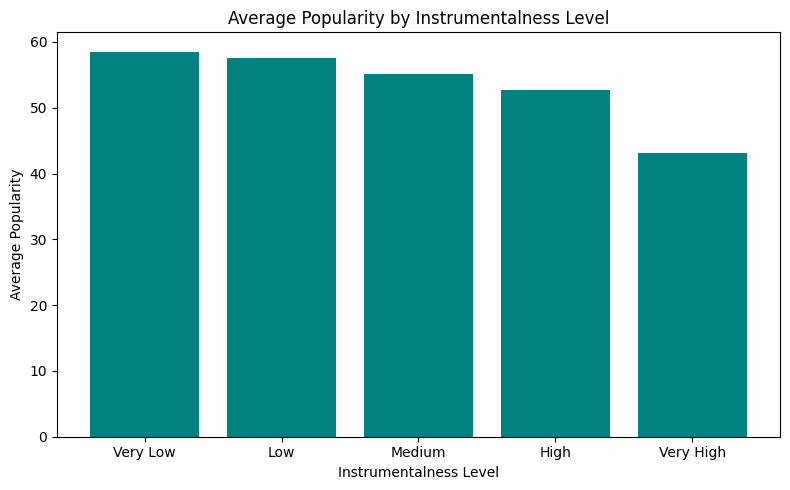

In [10]:

import pandas as pd
import matplotlib.pyplot as plt

bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['Instrumentalness_Bin'] = pd.cut(df['Instrumentalness'], bins=bins, labels=labels)

grouped = df.groupby('Instrumentalness_Bin')['Popularity'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(grouped['Instrumentalness_Bin'], grouped['Popularity'], color='teal')
plt.title('Average Popularity by Instrumentalness Level')
plt.xlabel('Instrumentalness Level')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()


*Visual Explanation*

The count plot categorizes the continuous instrumentalness variable into binned ranges (Very Low to High), enabling frequency distribution analysis.
A large majority of tracks fall into the "Very Low" instrumentalness bin, indicating that instrumental-heavy songs were rare in this dataset.
This supports the hypothesis that popular 1990s tracks emphasized vocals, consistent with the cultural dominance of R&B, pop, and hip-hop, which prioritize lyrics and vocal performance.
This frequency distribution provides insights for feature importance analysis—suggesting that low instrumentalness may correlate positively with track popularity.
It also demonstrates how feature engineering, such as binning continuous variables, can reveal clearer categorical trends.